# Using Graph Searches to Produce Matrix Inverse Algorithms

By Gabriel M. Perry, Micah H. Olson, David Grimsman, and Sean Warnick

In association with IDeA Labs, BYU, Provo, Utah, USA 84604

Colab Notebook by Gabriel Perry and Micah Olson

This Jupyter notebook is a companion illustration for our paper of the same title,
which can be found in the proceedings of the 2024 Conference on Decision and Control (CDC).
The algorithms explained in that paper are implemented here for illustrative purposes, and we exerted little effort to optimize these implementations.
Our focus was on the production of matrix inverse algorithms by applying graph search algorithms to a flow graph $Q=I-M$.
In the paper, we discuss four algorithms:

* Depth-First Search produces Mason's gain formula
* Breadth-First Search produces a Taylor polynomial
* Priority Search introduces intermediate rounding
* Bidirectional Search introduces an in-horizon filter

Of particular note is our contribution, Bidirectional Search.
When we applied this graph search to the flow graph $Q$,
the resulting matrix inverse algorithm was not an intuitive variation on the other solutions.

This notebook is publicly available in association with the paper.
We are currently working with other algorithms in preparation for follow-up papers.
Anyone interested in this work can email Gabriel Perry at gmp99@byu.edu. We would also be interested in any feedback provided,
including optimization, clarification, or extensions of this set of algorithms.

In [ ]:
do_forward_error = False # True to test error of Mu against e_j instead
show_gauss = False # toggles sampling and plotting
data_location = '/content/drive/MyDrive'

gauss_cutoff = 2e2 # stop sampling (dramatically improves runtimes)
power_series_cutoff = 1e4 # 3e5 stop sampling (optional) ALSO STOPS ACTUAL ERROR MEASUREMENTS
absolute_cutoff = 1.3e7 # 3e5 for 12.7 GB with power series; without 1.3e7 for s=2, 7.6e6 for s=5

## Auxillary Functions

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import time
import traceback
from collections import defaultdict
from google.colab import drive
drive.mount('/content/drive')

# the location of a persistant appended-to data file
if do_forward_error:
  filename = data_location + '/bidir_matmul_forward.csv' # error of Mu against e_j (doesn't account for conditioning)
else:
  filename = data_location + '/bidir_matmul_back.csv' # error of u against M inv (takes longer)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title A method for measuring norms of an ndarray
def measure(arr, norm=1):
  if np.size(arr) == 0:
    return 0.0
  if norm == 0:
    return np.count_nonzero(arr)
  if norm == 1:
    return np.sum(np.abs(arr))
  if norm == 2:
    return np.sqrt(np.sum(np.square(arr))) # add np.abs on inside to use with complex numbers
  if norm == np.inf:
    return np.max(np.abs(arr))

### Adjacency List Logic

In [ ]:
# @title generate an adjacency list (invertible matrix of size "size" with one to "num_out_edges" entries per column) with column sums "sum_of_each_column"
def generateSparseAdjacencyList(size, num_out_edges, sum_of_each_column, seed=None):
  if seed is not None:
    np.random.seed(seed)
  M_col = defaultdict(dict)
  M_row = defaultdict(dict)
  for i in range(size):
    # to guarantee the diagonal has some value in it, use {i:1}
    M_col[i] = {i:1}
    M_row[i] = {i:1}

  num_out_edges = min(num_out_edges, size)
  for cycle in range(num_out_edges):
    # generate num_out_edges permutations of size numbers
    perm = np.random.permutation(size)

    # each permutation is a path from prev to next, so the entries in the matrix are M[col][row] == M[perm[curr], perm[next]]
    # give these entries random values from -1 to 1
    # Actuslly generating Q here, M is later
    for index in range(size):
      val = np.random.random()*2 - 1
      M_col[perm[index]][perm[(index+1)%size]] = val
      M_row[perm[(index+1)%size]][perm[index]] = val

  # normalize the columns after we are done to sum to sum_of_each_column
  for col in range(size):
    magnitude = np.sum(np.abs(list(M_col[col].values()))) / sum_of_each_column
    for row in M_col[col].keys():
      # Q, not M, needs to have spectral radius less than 1, so perform I-Q here
      val = (row==col) - M_col[col][row] / magnitude
      M_col[col][row] = val
      M_row[row][col] = val

  return M_row, M_col

In [ ]:
#@title On-the-fly access of Q given M
def get_Q(M, row, col): # Q = I - M
  return (row == col) - M[col][row]

In [ ]:
#@title convert a dict to an ndarray
def dict_to_vect(vect, size):
  array = np.zeros((size,))
  for key in vect.keys():
    array[key] = vect[key]
  return array

def dict_to_mat(mat, size):
  array = np.zeros((size, size))
  for key in mat.keys():
    array[:,key] = dict_to_vect(mat[key], size)
  return array

In [ ]:
#@title A method for measuring norms of an adjacency list (vect or mat)
def measure_dict_vect(vect, norm=1):
  return measure(list(vect.values()))

def measure_dict_mat(matrix, norm=1):
  magnitude = 0.0
  for key in matrix.keys():
    magnitude += measure_dict_vect(matrix[key], norm)
  if norm == 0:
    return int(magnitude)
  return magnitude

In [ ]:
#@title Add two vectors (adjacency lists)
def add_vects(left, right):
  for row in right.keys():
    if row in left.keys():
      left[row] += right[row]
    else:
      left[row] = right[row]
  return left, len(right.keys())

In [ ]:
#@title Multiply a matrix[column, row] on the right by a column vector u
def dict_mat_mult(M, u, epsilon=0.0):
  y = defaultdict(float) # y = Mu
  FLOPs = 0
  for col in u.keys() & M.keys():
    FLOPs += 2 * len(M[col]) # for multiplication
    for row in M[col].keys():
      y[row] += M[col][row] * u[col] # the column of M matches the row of u
      if abs(y[row]) <= epsilon:
        del y[row]
  return y, FLOPs

In [ ]:
#@title A function for multiplying a vector by Q
def mul_Q_left(M, vect, epsilon=0.0): ### This function is a real bottleneck ###
  y = defaultdict(float) # y = M * vect
  FLOPs = 0
  for col in vect.keys():
    FLOPs += 2 * len(M[col])
    for row in M[col].keys(): # M always has entries on the diagonal (as no diagonal entry of Q can reach 1)
      y[row] += get_Q(M, row, col) * vect[col] # the column of M matches the row of vect
      if abs(y[row]) < epsilon:
        del y[row]
  return y, FLOPs

### Methods

In [ ]:
# @title Gaussian Elimination
# source: https://www.javatpoint.com/gaussian-elimination-in-python  (modified to work with adjacency lists)
def gaussian_inv_dict(M_dict, j, verbose=0, **kwargs):
  M = copy.deepcopy(M_dict)
  size = len(list(M.keys()))  # assume it is invertible, so every column has nonzero entries
  M[size] = {j:1}

  FLOPs = 0

  for pivot in range(0, size):
    # Searching the maximum value in the pivot column (don't count these FLOPs as a smarter method could do this live)
    max_el = 0
    max_row = pivot
    for row in M[pivot].keys():
      if row < pivot:
        continue
      if abs(M[pivot][row]) > max_el:
        max_el = abs(M[pivot][row])
        max_row = row

    # make the max row the pivot row (don't count these FLOPs as a smarter method could alias the operations in-place)
    for col in range(pivot, size+1):
      if max_row in M[col].keys():
        temp = M[col][max_row]
      else:
        temp = 0
      if pivot in M[col].keys():
        M[col][max_row] = M[col][pivot]
      else:
        if max_row in M[col].keys():
          del M[col][max_row]
      if temp != 0:
        M[col][pivot] = temp
      else:
        if pivot in M[col].keys():
          del M[col][pivot]

    # scale the pivot row to have 1-diagonal
    for col in range(size, pivot-1, -1):
      if pivot in M[col].keys():
        M[col][pivot] /= M[pivot][pivot]
        FLOPs += 1 # for division

    # Changing the value of the rows other than the diagonal (pivot) to 0 in the pivot column
    for row in M[pivot].keys():
      if row == pivot: # don't touch the pivot row
        continue

      leading = M[pivot][row]

      for col in range(size, pivot-1, -1):
        if row not in M[col].keys():
          M[col][row] = 0.0
        if pivot in M[col].keys():
          M[col][row] -= leading * M[col][pivot] # other rows, subtract pivot row scaled to make pivot column zero
          FLOPs += 2 # multiplication and subtraction

  return M[size], FLOPs, len(M_dict) # in O(n^3)

In [ ]:
# @title Power series with cutoff only (Breadth-First Search)
def pow_estimate_dict(M, j, max_iterations=10, epsilon=10**-3, verbose=0, **kwargs):
  u = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {j:1} # e_j

  FLOPs = 0
  COLS = set()

  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M,u,epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M, curr) # do not round
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure(list(curr.values()))
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < epsilon: # use epsilon as a cut off (if ||curr||_1 < epsilon, no entry is > epsilon), mostly for practical purposes here
      break

  return u, FLOPs, len(COLS) # in O(i s n)

In [ ]:
# @title Power series with intermediate rounding (Priority Search)
def pow_estimate_epsilon_dict(M, j, max_iterations=10, epsilon=10**-3, verbose=0, **kwargs):
  u = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {j:1} # e_j

  FLOPs = 0
  COLS = set()

  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M,u,epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < epsilon: # use epsilon as a cut off (if ||curr||_1 < epsilon, no entry is > epsilon)
      break

  return u, FLOPs, len(COLS) # in O(i s p)

In [ ]:
# @title Informed Power series (Bidirectional Search)
def bidir_dict(M_col, j, M_row, i, max_iterations=10, epsilon=10**-3, verbose=0, **kwargs):
  in_horiz = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {i:1} # e_j
  sqrt_epsilon = np.sqrt(epsilon)

  FLOPs = 0
  COLS = set()

  # find the sink in-horizon out to sqrt(epsilon)
  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M_row, in_horiz, epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    in_horiz, flops = add_vects(in_horiz, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M_row, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"|| e_{i}^T Q^k|| = {magnitude:.4f}")
    if magnitude < sqrt_epsilon: # use sqrt epsilon as a cut off (if ||curr||_1 < sqrt epsilon, no entry is > sqrt epsilon)
      break

  u = {} # u ~ M^-1e_j = (I-Q)^-1e_j = e_j + Qe_j + Q^2e_j + Q^3e_j + Q^4e_j + ...
  curr = {j:1} # e_j

  # find the source out-horizon out to sqrt(epsilon)
  for iter in range(max_iterations):
    if verbose > 1:
      print(dict_mat_mult(M_col, u, epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M_col, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    # COLS |= curr.keys() ################## ACTUALLY ROWS NOT COLUMNS - CAN OVER OR UNDERESTIMATE ########################

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < sqrt_epsilon: # use sqrt epsilon as a cut off (if ||curr||_1 < sqrt epsilon, no entry is > sqrt epsilon)
      break

  # continue the source out-horizon only within the sink in-horizon
  for iter in range(max_iterations):
    # round down everything in u not in the in-horizon
    for row in list(curr.keys()):
      if row not in in_horiz:
        del curr[row]

    if verbose > 1:
      print(dict_mat_mult(M_col,u,epsilon))

    # save the flow to the current estimate - the column of M equals the row of u in the multiplication
    u, flops = add_vects(u, curr)
    FLOPs += flops

    # compute the new fringe flows Q^(k+1)e_j = Q * (Q^k)e_j
    curr, flops = mul_Q_left(M_col, curr, epsilon) # round entries below epsilon
    FLOPs += flops
    COLS |= curr.keys()

    magnitude = measure_dict_vect(curr)
    if verbose > 0 and iter%5 == 0:
      print(f"||Q^k e_{j}|| = {magnitude:.4f}")
    if magnitude < epsilon: # use epsilon as a cut off (if ||curr||_1 < epsilon, no entry is > epsilon)
      break

  return u, FLOPs, len(COLS) # in O(i s sqrt(p))

### Test Drivers

In [ ]:
#@title A single-run driver for a general method
def test_method(M_dict, sample, method, **kwargs):

  M_inv = {}
  FLOPs = 0.0
  unique_cols = 0.0

  start_time = time.time()
  for col in sample:
    u, flops, cols = method(M_dict, col, **kwargs)
    FLOPs += float(flops) / sample.size # avg FLOPs across each column (test each column)
    unique_cols += float(cols) / sample.size # avg num unique cols requested
    M_inv[col] = u # save all estimates
  end_time = time.time()

  return M_inv, FLOPs, unique_cols, (end_time - start_time) / sample.size # avg runtime per estimated column

In [ ]:
# #@title Measure the error (forward: Mu - e_j OR backward: u - M_inv_j)
# def error(M_inv, n, sample, **kwargs):

#   # for Bidir only check the target entry, not the entire column
#   if 'i' in kwargs:
#     if 'actual_M_inv' in kwargs and kwargs['actual_M_inv'] is not None:
#       diff = kwargs['actual_M_inv'][kwargs['i'],:] - M_inv[kwargs['i'],:] # back error
#     else:
#       diff = M_inv[kwargs['i'],:] @ kwargs['actual_M_np'][sample,:] - np.identity(n)[kwargs['i'],:] # forward error

#   elif 'actual_M_inv' in kwargs and kwargs['actual_M_inv'] is not None:
#     diff = kwargs['actual_M_inv'] - M_inv # back error (considers conditioning)
#   else:
#     diff = M_inv @ kwargs['actual_M_np'][sample,:] - np.identity(n) # forward error (cheaper)

#   return measure(diff, np.inf)


#@title Measure the error (forward: Mu - e_j OR backward: u - M_inv_j)
def error(M_inv, n, sample, **kwargs):

  # for Bidir only check the target entry, not the entire column
  if 'i' in kwargs:
    if 'actual_M_inv' in kwargs and kwargs['actual_M_inv'] is not None:
      diff = kwargs['actual_M_inv'][kwargs['i'],:] - M_inv[kwargs['i'],:] # back error
    else:
      diff = kwargs['actual_M_np'][kwargs['i'],:] @ M_inv - np.identity(n)[kwargs['i'],sample] # forward error

  elif 'actual_M_inv' in kwargs and kwargs['actual_M_inv'] is not None:
    diff = kwargs['actual_M_inv'] - M_inv # back error (considers conditioning)
  else:
    diff = kwargs['actual_M_np'] @ M_inv - np.identity(n)[:,sample] # forward error (cheaper)

  return measure(diff, np.inf)

In [ ]:
#@title Run the test and collect the data
def use_method(M_dict, n, sample, method, **kwargs):

  # run the method
  M_inv, FLOPs, unique_cols, runtime = test_method(M_dict, sample, method, **kwargs)

  if n < power_series_cutoff:
    # if we are measuring forward error, do the overhead work here
    if 'actual_M_inv' not in kwargs or kwargs['actual_M_inv'] is None:
      kwargs['actual_M_np'] = dict_to_mat(M_dict, n)

    # only keep the columns we estimated
    M_inv = dict_to_mat(M_inv, n)[:,sample]
    inf_norm_error = error(M_inv, n, sample, **kwargs)
  else:
    inf_norm_error = 1.0

  del M_inv

  print(f", {runtime:.2f} min", end='')
  return FLOPs, inf_norm_error, unique_cols, runtime

In [ ]:
#@title A test driver to run all methods on one sample point
def run_all(M_row, M_col, n, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=500, i=1, show_gauss=False):

  # only compute the exact inverse once, only if we use it for backward error
  if do_forward_error and n < power_series_cutoff:
    actual_M_inv = np.linalg.pinv(dict_to_mat(M_col, n))[:,sample]
  else:
    actual_M_inv = None

  # sample the columns
  sample_size = min(n, 30)
  sample = np.random.randint(low=0, high=n, size=sample_size, dtype=int)

  # run the methods and collect the data
  if show_gauss and n < gauss_cutoff: Gauss_data = use_method(M_col, n, sample, gaussian_inv_dict, actual_M_inv=actual_M_inv)
  else: Gauss_data = (1, 1, 1, 1)

  if n < power_series_cutoff: Pow_data = use_method(M_col, n, sample, pow_estimate_dict, max_iterations=max_iterations, epsilon=pow_epsilon, actual_M_inv=actual_M_inv, verbose=0)
  else: Pow_data = (1, 1, 1, 1)

  Pri_data = use_method(M_col, n, sample, pow_estimate_epsilon_dict, max_iterations=max_iterations, epsilon=pri_epsilon, actual_M_inv=actual_M_inv, verbose=0)

  Bidir_data = use_method(M_col, n, sample, bidir_dict, M_row=M_row, i=i, max_iterations=max_iterations, epsilon=bid_epsilon, actual_M_inv=actual_M_inv, verbose=0)

  return [Gauss_data, Pow_data, Pri_data, Bidir_data]

In [ ]:
#@title Append to a File (iterate over n)
def sample_and_save(samples, filename='/content/drive/My Drive/samples.csv', sparcity=np.sqrt, Q_spectral_radius=0.7, i=1, pow_epsilon=1e-5, pri_epsilon=1e-5, bid_epsilon=1e-5, max_iterations=500, show_gauss=False, verbose=0):
  try:
    # Try to load existing data
    df = pd.read_csv(filename)
  except FileNotFoundError:
    # Create a new DataFrame if file doesn't exist
    df = pd.DataFrame()

  try:

    iteration = 0
    print()
    print("Sample #, matrix size, sparcity, generation time, (Gauss), power series, rounded, bidirectional. Sample size/times, (wasted time)", end='')

    for n in samples:

      # set up the size and sparcity, reject large sizes
      n,s = int(n), int(sparcity(n))
      print()
      iteration += 1
      print(f"{iteration}: n={n}, s={s}", end='')
      if n >= absolute_cutoff:
        print(" (too big)", end='')
        iteration -= 1
        continue

      # generte the matrix
      start_time = time.time()
      M_row, M_col = generateSparseAdjacencyList(size=n, num_out_edges=s, sum_of_each_column=Q_spectral_radius, seed=None)

      # run the methods and collect the data
      data = run_all(M_row=M_row, M_col=M_col, n=n, pow_epsilon=pow_epsilon, pri_epsilon=pri_epsilon, bid_epsilon=bid_epsilon, max_iterations=max_iterations, show_gauss=show_gauss, i=i)
      del M_row, M_col

      # Create a new data point DataFrame
      new_sample = pd.DataFrame(columns = ['Computed', 'n', 's', 'Avg. FLOPs', 'Cols Fetched', 'Avg. Linf Error', 'Time'])
      if show_gauss and n < gauss_cutoff:
        new_sample.loc[len(new_sample.index)] = ['Gauss', n, s, np.log10(data[0][0]), np.log10(data[0][2]), np.log10(data[0][1]), np.log10(data[0][3])]
      if n < power_series_cutoff:
        new_sample.loc[len(new_sample.index)] = ['Power', n, s, np.log10(data[1][0]), np.log10(data[1][2]), np.log10(data[1][1]), np.log10(data[1][3])]
      new_sample.loc[len(new_sample.index)] = ['Priority', n, s, np.log10(data[2][0]), np.log10(data[2][2]), np.log10(data[2][1]), np.log10(data[2][3])]
      new_sample.loc[len(new_sample.index)] = ['Bidir', n, s, np.log10(data[3][0]), np.log10(data[3][2]), np.log10(data[3][1]), np.log10(data[3][3])]
      del data

      # Append sample to DataFrame
      df = pd.concat((df, new_sample), ignore_index=True)

      # Save updated DataFrame to Google Drive
      df.to_csv(filename, index=False)

      print(f", ({(time.time()-start_time-(10**new_sample['Time']).sum())/60:.2f})", end='')

  except: # If the data collection is inturrupted,
    print()
    print(f"Execution ended by exception after {iteration} samples")
    traceback.print_exc()
  else:
    print()
    print(f"Saved {iteration} samples to {filename}")
  finally:
    pass

In [ ]:
#@title Plot data
def plot_one(df, title, xlabel, ylabel, line, xvar, yvar, alpha=0.2, show_gauss=False):
  plt.title(title)
  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  if line is not None:
    x = np.linspace(np.log10(5), np.log10(absolute_cutoff), 100)
    plt.plot(x, line(x), linestyle='dashed', color='red')

  if show_gauss:
    plt.scatter(df[df['Computed'] == 'Gauss'][xvar], df[df['Computed'] == 'Gauss'][yvar], color='blue', alpha=alpha, label='Gauss')
  plt.scatter(df[df['Computed'] == 'Power'][xvar], df[df['Computed'] == 'Power'][yvar], color='red', alpha=alpha, label='Power')
  plt.scatter(df[df['Computed'] == 'Priority'][xvar], df[df['Computed'] == 'Priority'][yvar], color='black', alpha=alpha, label='Rounded')
  plt.scatter(df[df['Computed'] == 'Bidir'][xvar], df[df['Computed'] == 'Bidir'][yvar], color='green', alpha=alpha, label='Bidir')
  plt.legend()
  plt.show()

## Data Collection

In [ ]:
# filename = '/content/bidir_matmul_back.csv' # error of u against M inv (takes longer)
num_samples = 0 # number of samples taken
min_n = 200 # MIN 2: for range tests, the minimum size of the samples
max_n = 200 # for range tests, the maximum size of the samples
sparcity_func = lambda x:500 # = lambda x:np.random.randint(low=101, high=1001) # = lambda x:int(1+np.log10(x)) # = lambda x:int(np.sqrt(x)) # = lambda x:4

'use a log-space uniform distribution'
samples = np.power(np.full(fill_value=10, shape=(num_samples,)), (np.random.uniform(low=np.log10(min_n), high=np.log10(max_n), size=num_samples)))
'use an exp onential distribution'
# samples = min_n + np.random.exponential(scale=max_n, size=num_samples)
'sort (tradeoff: if you end early, you lose the larger and more costly samples)'
samples.sort()
'or reverse the list to do the big ones first'
# samples = samples.tolist()
# samples.reverse()

sample_and_save(samples=samples, sparcity=sparcity_func, filename=filename, show_gauss=show_gauss)


Sample #, matrix size, sparcity, generation time, (Gauss), power series, rounded, bidirectional. Sample size/times, (wasted time)
Saved 0 samples to /content/drive/MyDrive/bidir_matmul_back.csv


## Display Data

In [ ]:
#@title Read data from file
df = pd.read_csv(filename)
### if the dimension is n, take the log seperately ###
df.n = df.n.apply(np.log10)
df.s = df.s.apply(np.log10)
print(f'Number of data points: {df.shape[0]}')
alpha = 0.2

# Option to only show s=2,5,20
df4 = df[df['s'] == np.log10(2)]
df4 = pd.concat((df4, df[df['s'] == np.log10(5)]), ignore_index=True)
df4 = pd.concat((df4, df[df['s'] == np.log10(20)]), ignore_index=True)
df4 = pd.concat((df4, df[df['s'] == np.log10(500)]), ignore_index=True)

Number of data points: 6363


In [ ]:
df[['n','s','Time', 'Avg. FLOPs', 'Cols Fetched','Avg. Linf Error']].corr()

,n,s,Time,Avg. FLOPs,Cols Fetched,Avg. Linf Error
n,1.000000,-0.002795,0.692071,0.685887,0.813368,0.581949
s,-0.002795,1.000000,0.387360,0.381827,0.091934,0.456376
Time,0.692071,0.387360,1.000000,0.995780,0.913953,0.485162
Avg. FLOPs,0.685887,0.381827,0.995780,1.000000,0.915947,0.470372
Cols Fetched,0.813368,0.091934,0.913953,0.915947,1.000000,0.427202
Avg. Linf Error,0.581949,0.456376,0.485162,0.470372,0.427202,1.000000


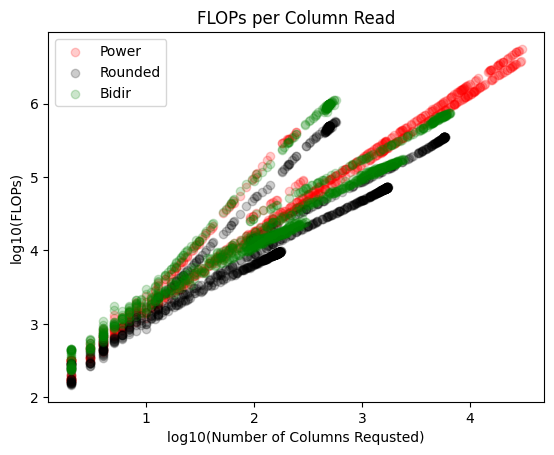

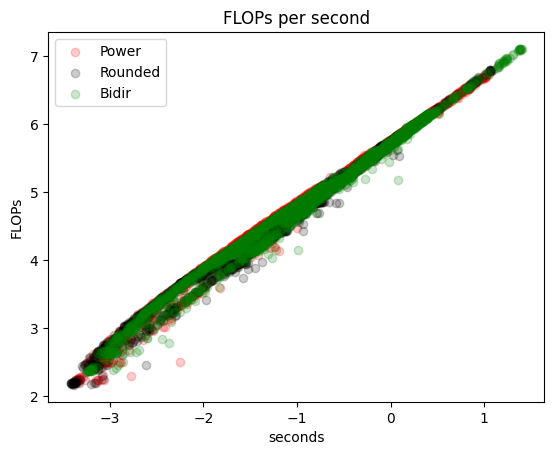

In [ ]:
#@title Correlation Plots

# this is not a ratio (not accuracy / FLOPs). The rounded methods approach a limit to the right and stay there, not moving downward.
# plot_one(df, "Accuracy per FLOP", "log10(FLOPs)", "log10(|M_ij - u|_infty)", None, 'Avg. FLOPs', 'Avg. Linf Error', show_gauss=show_gauss)
# See above comment
# plot_one(df, "Accuracy per Column Read", "log10(Number of Columns Requsted)", "log10(|M_ij - u|_infty)", None, 'Cols Fetched', 'Avg. Linf Error', show_gauss=show_gauss)
plot_one(df4, "FLOPs per Column Read", "log10(Number of Columns Requsted)", "log10(FLOPs)", None, 'Cols Fetched', 'Avg. FLOPs', show_gauss=show_gauss)
# points above the diagonal are acheiving more FLOPs / second, possibly by having more cache hits
plot_one(df, "FLOPs per second", "seconds", "FLOPs", None, 'Time', 'Avg. FLOPs', show_gauss=show_gauss)

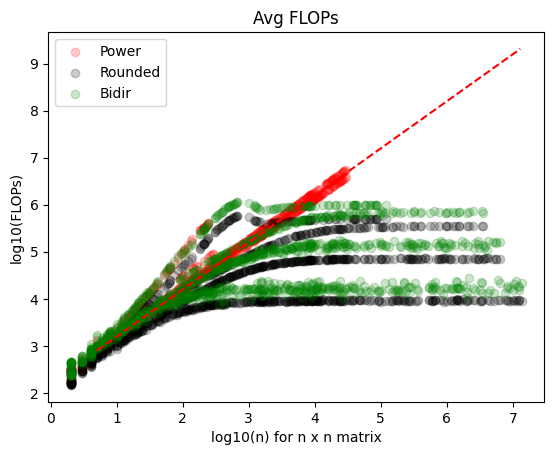

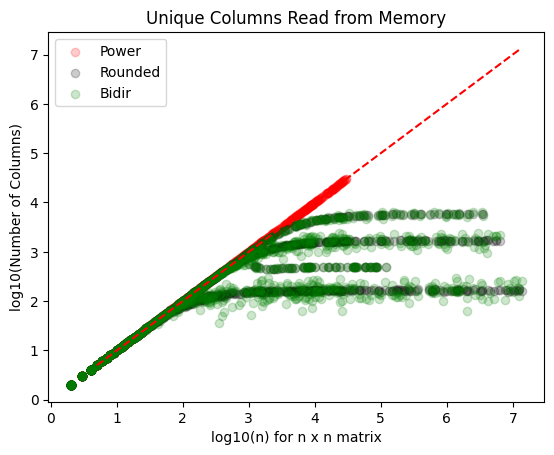

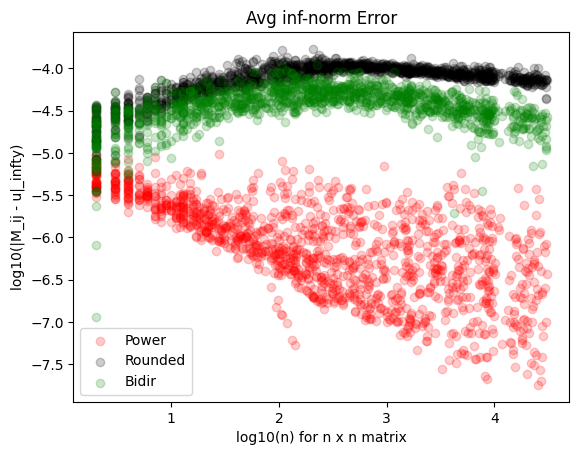

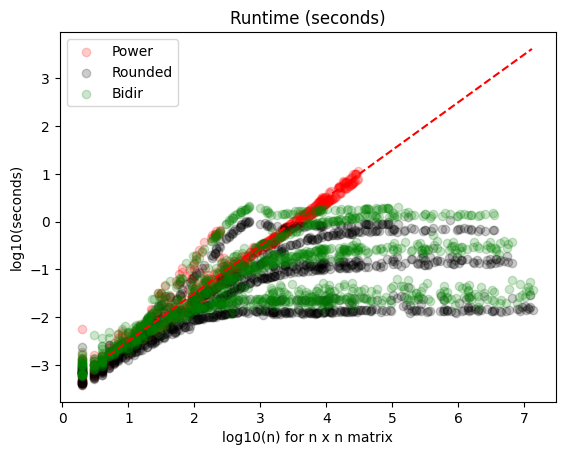

In [ ]:
#@title Plots against Matrix Size

# rounded methods reach a limit (which, as spectral radius and epsilon are held constant, the bands are from the sparcities)
plot_one(df4, "Avg FLOPs", "log10(n) for n x n matrix", "log10(FLOPs)", lambda x: x+2.2, 'n', 'Avg. FLOPs', alpha=alpha, show_gauss=show_gauss)
# see above comment
plot_one(df4, "Unique Columns Read from Memory", "log10(n) for n x n matrix", "log10(Number of Columns)", lambda x: x, 'n', 'Cols Fetched', alpha=alpha, show_gauss=show_gauss)
# The triangle on the power series seems to appear often. Note that the rounded methods hang out around their epsilon values.
df2 = df[df['Avg. Linf Error'] < -2]
plot_one(df2, "Avg inf-norm Error", "log10(n) for n x n matrix", "log10(|M_ij - u|_infty)", None, 'n', 'Avg. Linf Error', alpha=alpha, show_gauss=show_gauss)
# Contrary to the FLOPs and the runtime ratio,
plot_one(df4, "Runtime (seconds)", "log10(n) for n x n matrix", "log10(seconds)", lambda x: x-3.5, 'n', 'Time', alpha=alpha, show_gauss=show_gauss)

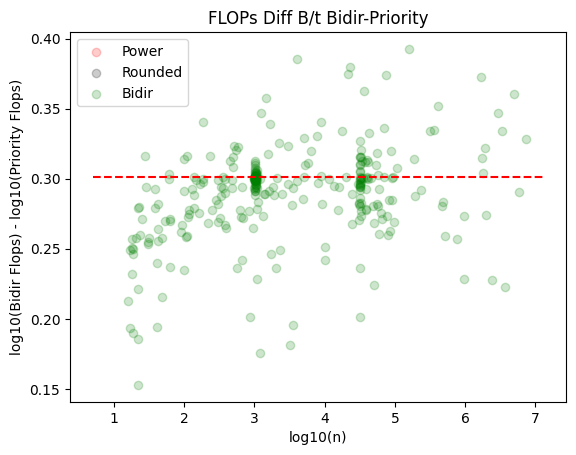

In [ ]:
#@title prompt: In the dataframe df, select all objects of type Bidir and Priotity and compare the difference in Avg. # of FLOPs between nearby objects with the same n and s fields

# low sparcities have more variance
df6 = df[df['s'] > np.log10(3)]
df6 = df6[df6['n'] > 1.2]


# Select Bidir and Priority objects
df_bidir = df6[df6['Computed'] == 'Bidir']
df_priority = df6[df6['Computed'] == 'Priority']

# Merge the two dataframes on 'n' and 's' to find nearby objects
merged_df = pd.merge(df_bidir, df_priority, on=['n', 's'], suffixes=('_bidir', '_priority'))

# Calculate the difference in Avg. # of FLOPs
merged_df['FLOPs_diff'] = merged_df['Avg. FLOPs_bidir'] - merged_df['Avg. FLOPs_priority']
merged_df['Computed'] = df6[df6['Computed'] == 'Bidir']['Computed']

# Print the differences
merged_df[['n', 'FLOPs_diff']]
plot_one(merged_df, "FLOPs Diff B/t Bidir-Priority", "log10(n)", "log10(Bidir Flops) - log10(Priority Flops)", lambda x:np.ones_like(x) * np.log10(2), 'n', 'FLOPs_diff', show_gauss=show_gauss)


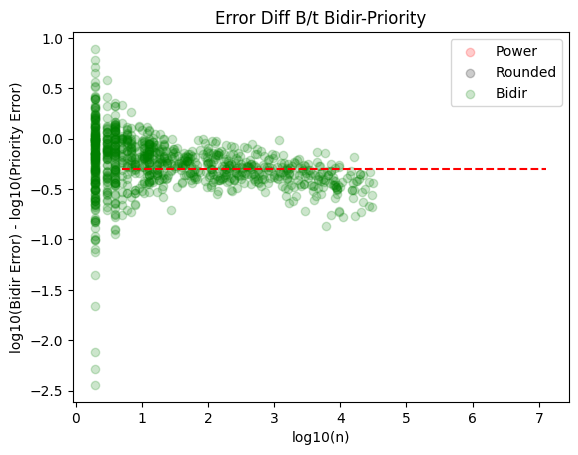

In [ ]:
#@title same as above but error

# low sparcities have more variance
df6 = df2#[df2['s'] > np.log10(3)]


# Select Bidir and Priority objects
df_bidir = df6[df6['Computed'] == 'Bidir']
df_priority = df6[df6['Computed'] == 'Priority']

# Merge the two dataframes on 'n' and 's' to find nearby objects
merged_df = pd.merge(df_bidir, df_priority, on=['n', 's'], suffixes=('_bidir', '_priority'))

# Calculate the difference in Avg. # of FLOPs
merged_df['ERR_diff'] = merged_df['Avg. Linf Error_bidir'] - merged_df['Avg. Linf Error_priority']
merged_df['Computed'] = df6[df6['Computed'] == 'Bidir']['Computed']

# Print the differences
merged_df[['n', 'ERR_diff']]
plot_one(merged_df, "Error Diff B/t Bidir-Priority", "log10(n)", "log10(Bidir Error) - log10(Priority Error)", lambda x:np.ones_like(x) * np.log10(0.5), 'n', 'ERR_diff', show_gauss=show_gauss)


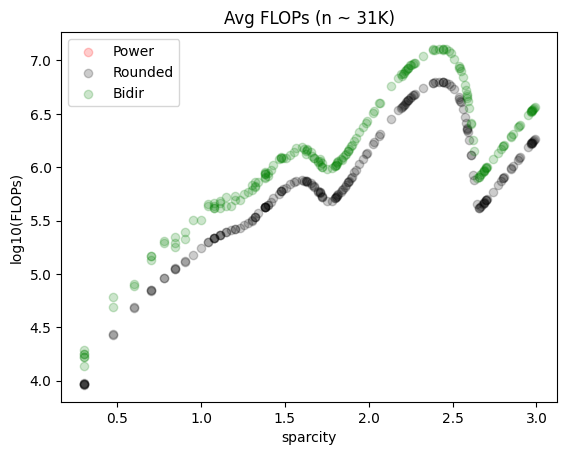

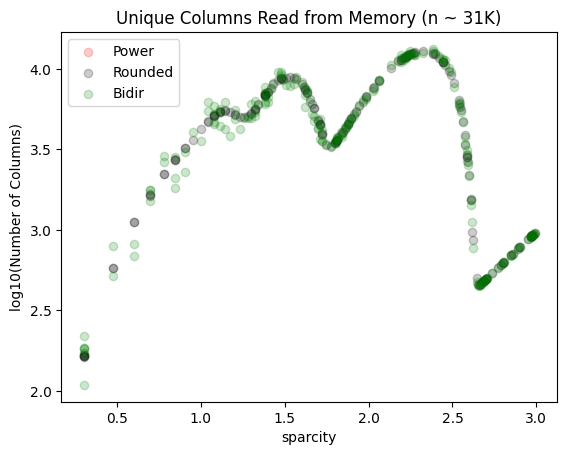

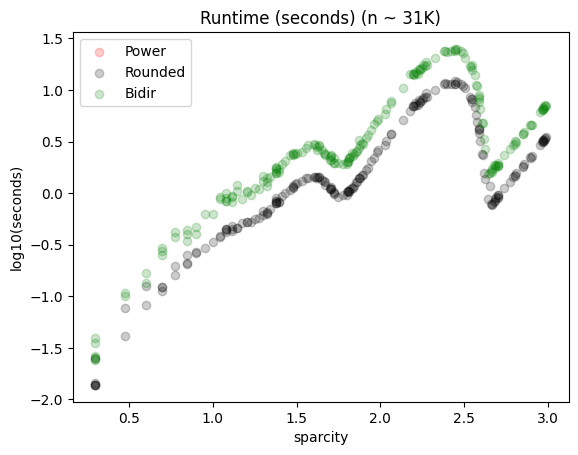

In [ ]:
#@title Plots against Sparcity
df3 = df[df['n'] > 4.5]
df3 = df3[df3['n'] < 4.6] # 4.5-4.6, OR 3.0-3.1
df3 = df3[df3.Computed != 'Power'] # 4.5-4.6, OR 3.0-3.1
alpha = 0.6

# df3 = df3[df3['s'] < 2.45] # 4.5-4.6, OR 3.0-3.1
# df3 = df3[df3['s'] > 2.255] # 4.5-4.6, OR 3.0-3.1


plot_one(df3, "Avg FLOPs (n ~ 31K)", "sparcity", "log10(FLOPs)", None, 's', 'Avg. FLOPs', show_gauss=show_gauss)
plot_one(df3, "Unique Columns Read from Memory (n ~ 31K)", "sparcity", "log10(Number of Columns)", None, 's', 'Cols Fetched', show_gauss=show_gauss)
# plot_one(df3, "Avg inf-norm Error", "sparcity", "log10(|M_ij - u|_infty)", None, 's', 'Avg. Linf Error', show_gauss=show_gauss)
plot_one(df3, "Runtime (seconds) (n ~ 31K)", "sparcity", "log10(seconds)", None, 's', 'Time', show_gauss=show_gauss)

TO DO:

* Make an adjacency list class that builds matrices dynamically instead of stores the entire list (store seeds for each permutation, scales for each column).
* Make a built-in mat mult (use dicts, not cast to numpy arrays) - see use_method() calls to dict_to_mat. Actually, always cast to numpy?
* mul_Q_left is also slow, as will be the homemade mat mult function